In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

In [2]:
sns.set_style("whitegrid")

In [3]:
from google.colab import files

In [4]:
uploaded=files.upload()

Saving used_cars.csv to used_cars.csv


In [5]:
df = pd.read_csv("used_cars.csv")

In [6]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [7]:
df.shape

(4009, 12)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [9]:
df.describe()

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


In [10]:
df.describe(include="object")

,brand,model,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
count,4009,4009,4009,3839,4009,4009,4009,4009,3896,3413,4009
unique,57,1898,2818,7,1146,62,319,156,2,1,1569
top,Ford,M3 Base,"110,000 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,A/T,Black,Black,None reported,Yes,"$15,000"
freq,386,30,16,3309,52,1037,905,2025,2910,3413,39


In [11]:
df.columns

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='object')

In [12]:
df.isnull().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,170
engine,0
transmission,0
ext_col,0
int_col,0
accident,113


In [13]:
(df.isnull().sum()/len(df))*100

,0
brand,0.000000
model,0.000000
model_year,0.000000
milage,0.000000
fuel_type,4.240459
engine,0.000000
transmission,0.000000
ext_col,0.000000
int_col,0.000000
accident,2.818658


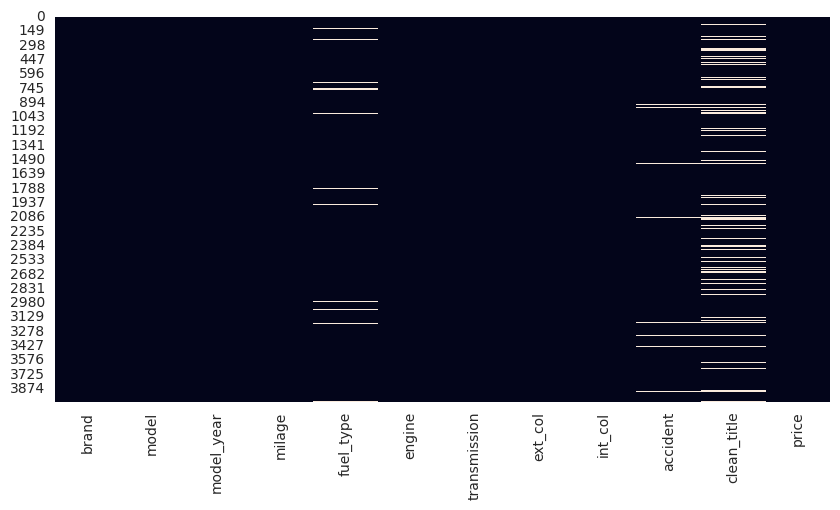

In [14]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(),cbar=False)
plt.show()

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
numerical=df.select_dtypes(include=np.number).columns

categorical=df.select_dtypes(include="object").columns

print(numerical)
print(categorical)

Index(['model_year'], dtype='object')
Index(['brand', 'model', 'milage', 'fuel_type', 'engine', 'transmission',
       'ext_col', 'int_col', 'accident', 'clean_title', 'price'],
      dtype='object')


In [17]:
for col in categorical:
    print(col)
    print(df[col].value_counts())
    print("----------------")

brand
brand
Ford             386
BMW              375
Mercedes-Benz    315
Chevrolet        292
Porsche          201
Audi             200
Toyota           199
Lexus            163
Jeep             143
Land             130
Nissan           116
Cadillac         107
GMC               91
RAM               91
Dodge             90
Tesla             87
Kia               76
Hyundai           72
Subaru            64
Acura             64
Mazda             64
Honda             63
INFINITI          59
Volkswagen        59
Lincoln           52
Jaguar            47
Volvo             38
Maserati          34
Bentley           33
MINI              33
Buick             30
Chrysler          28
Lamborghini       26
Genesis           20
Mitsubishi        20
Alfa              19
Rivian            17
Hummer            16
Pontiac           15
Ferrari           12
Rolls-Royce       11
Aston              9
Scion              6
McLaren            6
Saturn             5
FIAT               5
Lotus              4
L

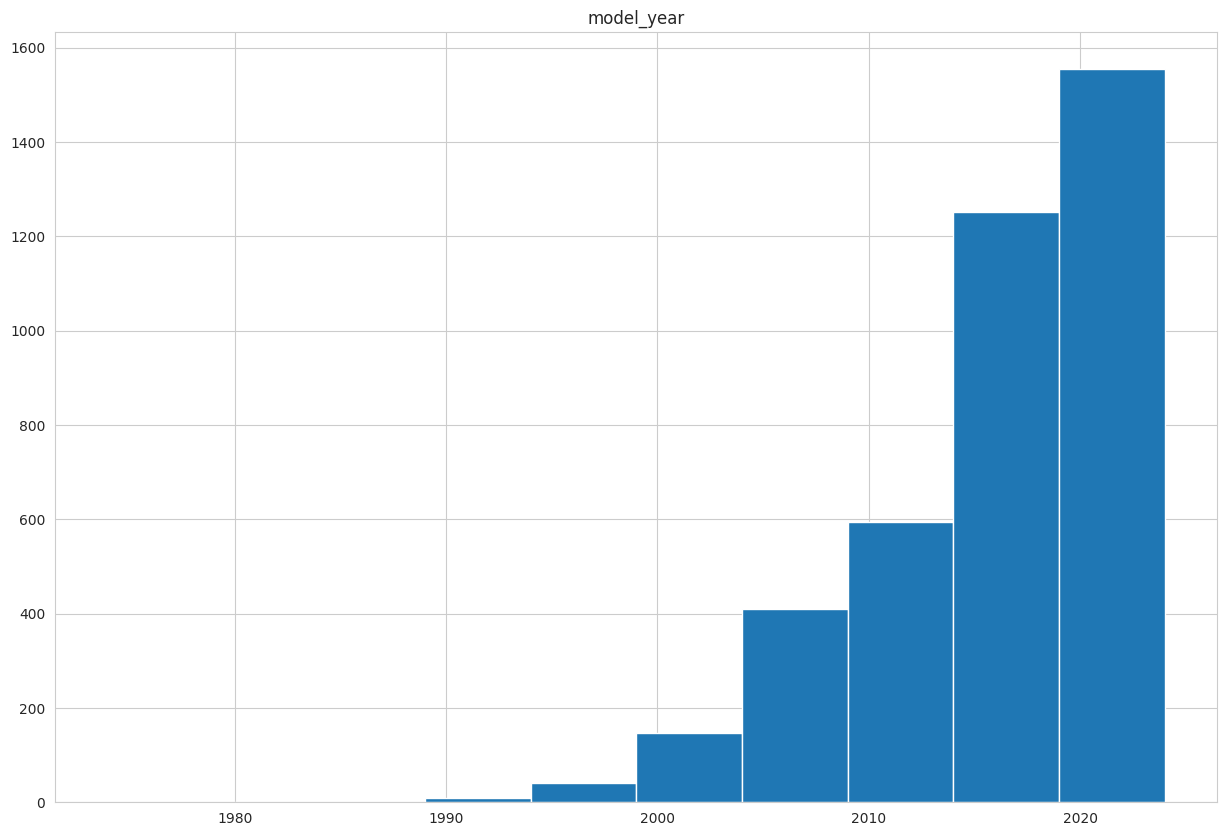

In [18]:
df[numerical].hist(figsize=(15,10))
plt.show()

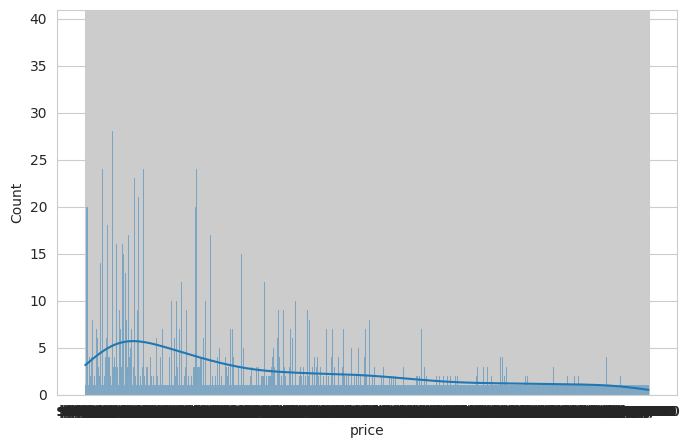

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"],bins=30,kde=True)
plt.show()

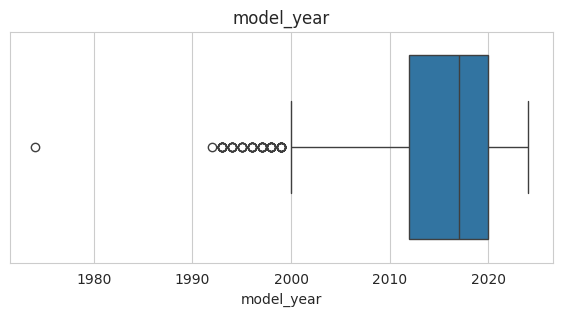

In [20]:
for col in numerical:
    plt.figure(figsize=(7,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

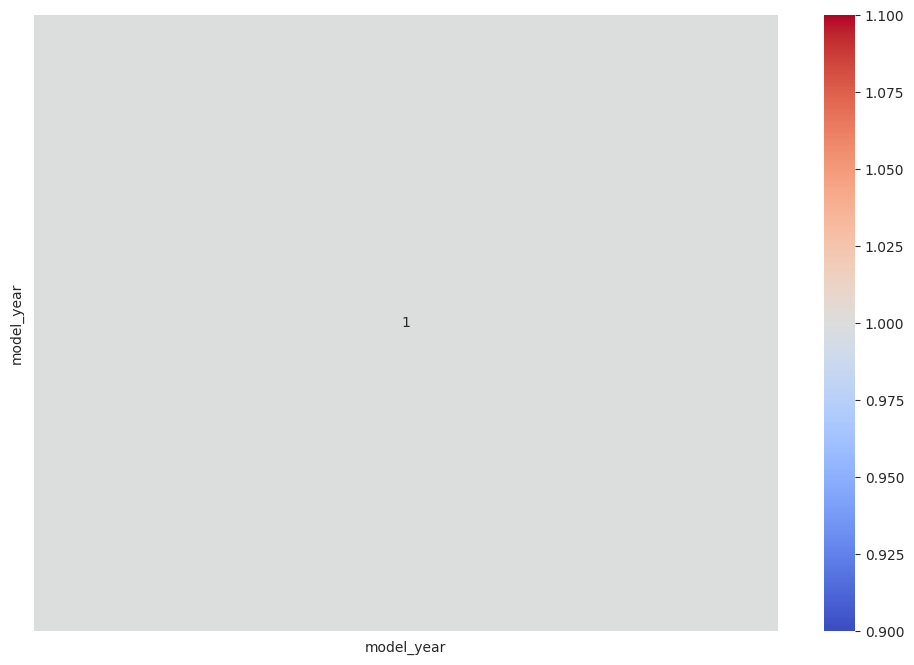

In [21]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

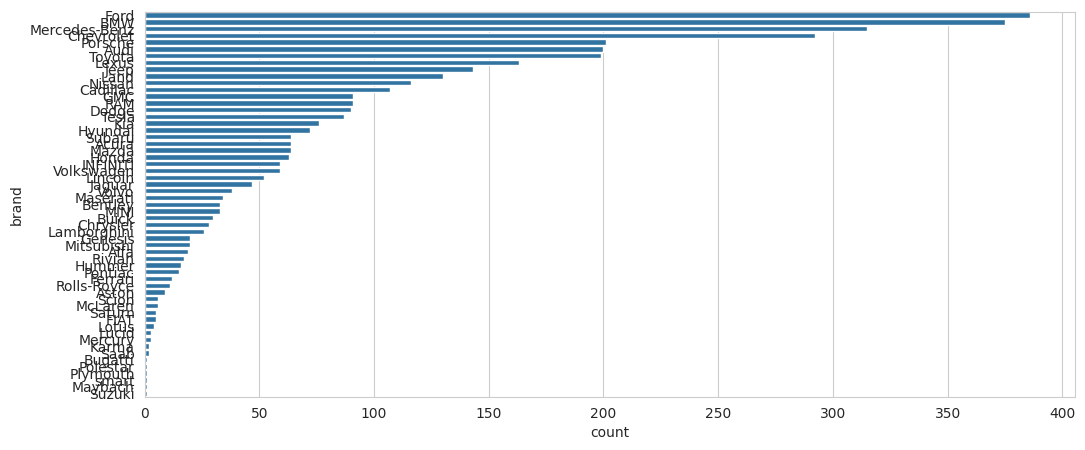

In [22]:
plt.figure(figsize=(12,5))

sns.countplot(data=df,
              y="brand",
              order=df["brand"].value_counts().index)

plt.show()

In [23]:
Q1=df["price"].quantile(.25)

Q3=df["price"].quantile(.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR

upper=Q3+1.5*IQR

outliers=df[(df["price"]<lower)|(df["price"]>upper)]

outliers

TypeError: unsupported operand type(s) for -: 'str' and 'str'

In [24]:
df["price"].dtype

dtype('O')

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [26]:
df["price"].head(10)

,price
0,"$10,300"
1,"$38,005"
2,"$54,598"
3,"$15,500"
4,"$34,999"
5,"$14,798"
6,"$31,000"
7,"$7,300"
8,"$41,927"
9,"$69,950"


In [27]:
df["price"].sample(10)

,price
2895,"$23,000"
1742,"$32,368"
3748,"$234,000"
2913,"$12,000"
1268,"$8,900"
2487,"$89,000"
25,"$32,300"
733,"$101,000"
2238,"$130,000"
762,"$31,900"


In [28]:
df["price"].str.contains(",", na=False).sum()

np.int64(4009)

In [29]:
df["price"].str.contains("\$", regex=True, na=False).sum()

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_1749/2111154301.py:1: SyntaxWarning: invalid escape sequence '\$'
  df["price"].str.contains("\$", regex=True, na=False).sum()


np.int64(4009)

In [30]:
df["price"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["price"] = pd.to_numeric(df["price"])

In [31]:
df["price"].head(10)

,price
0,10300
1,38005
2,54598
3,15500
4,34999
5,14798
6,31000
7,7300
8,41927
9,69950


In [32]:
print(df["price"].dtype)

int64


In [33]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["price"] < lower) | (df["price"] > upper)]

print(outliers.shape)
outliers.head()

(244, 12)


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
11,Aston,Martin DBS Superleggera,2019,"22,770 mi.",Gasoline,715.0HP 5.2L 12 Cylinder Engine Gasoline Fuel,8-Speed A/T,Silver,Black,None reported,Yes,184606
16,Mercedes-Benz,Metris Base,2021,"1,685 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,9-Speed Automatic,Gray,White,None reported,Yes,250000
44,Lucid,Air Grand Touring,2022,"3,552 mi.",NaN,536.0HP Electric Motor Electric Fuel System,1-Speed A/T,Red,Beige,None reported,Yes,119999
61,Audi,R8 5.2 V10,2018,"8,940 mi.",Gasoline,5.2L V10 40V PDI DOHC,7-Speed Automatic with Auto-Shift,Tango Red Metallic,Black,None reported,NaN,144900
71,Bentley,Continental GT W12,2017,"14,684 mi.",Gasoline,582.0HP 6.0L 12 Cylinder Engine Gasoline Fuel,8-Speed A/T,White,White,None reported,Yes,130000


In [34]:
df.isnull().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,170
engine,0
transmission,0
ext_col,0
int_col,0
accident,113


In [35]:
categorical = df.select_dtypes(include="object").columns

for col in categorical:
    df[col] = df[col].fillna(df[col].mode()[0])

In [36]:
numerical = df.select_dtypes(include="number").columns

for col in numerical:
    df[col] = df[col].fillna(df[col].median())

In [37]:
df.isnull().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,0
engine,0
transmission,0
ext_col,0
int_col,0
accident,0


In [38]:
print("Duplicates before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after:", df.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


In [39]:
df["milage"] = (
    df["milage"]
    .str.replace(",", "", regex=False)
    .str.replace(" mi.", "", regex=False)
)

df["milage"] = pd.to_numeric(df["milage"])

In [40]:
df["milage"].dtype

dtype('int64')

In [41]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["price"] >= lower) & (df["price"] <= upper)]

In [42]:
df.shape

(3765, 12)

In [43]:
CURRENT_YEAR = 2026

df["car_age"] = CURRENT_YEAR - df["model_year"]

In [44]:
df["milage_per_year"] = df["milage"] / (df["car_age"] + 1)

In [45]:
luxury = [
    "BMW",
    "Mercedes-Benz",
    "Audi",
    "Lexus",
    "Porsche",
    "Land",
    "Jaguar"
]

df["is_luxury"] = df["brand"].isin(luxury).astype(int)

In [46]:
df["price_per_mile"] = df["price"] / (df["milage"] + 1)

In [47]:
df["usage_category"] = pd.cut(
    df["milage"],
    bins=[0, 30000, 80000, 300000],
    labels=["Low", "Medium", "High"]
)

In [48]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,car_age,milage_per_year,is_luxury,price_per_mile,usage_category
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300,13,3642.857143,0,0.201957,Medium
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005,5,5790.333333,0,1.093889,Medium
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,Yes,54598,4,4474.400000,1,2.440352,Low
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500,11,7408.333333,0,0.174351,High
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,Yes,34999,5,1639.166667,1,3.558255,Low


In [49]:
df.to_csv("cleaned_used_cars.csv", index=False)

In [50]:
from google.colab import files
files.download("cleaned_used_cars.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>